In [ ]:
"""
=============================================================
 Multi-Armed Bandit (MAB) 시뮬레이션
=============================================================
 [문제 상황]
   카지노에 슬롯머신 5대(A~E)가 있다. 각 머신은 서로 다른 당첨 확률을 가지고 있지만, 플레이어는 이 확률을 사전에 알 수 없다.
   직접 레버를 당겨보며 경험을 쌓아 가장 보상이 높은 머신을 찾아야 한다.
   이것이 Multi-Armed Bandit 문제의 핵심이다.

 [환경 설계]
   - 슬롯머신 5대 : A(0.2), B(0.5), C(0.1), D(0.8), E(0.3)
     → 실제 당첨 확률은 코드 내부에만 존재하며, 에이전트는 모름
   - 보상 방식 : 베르누이 분포 (당첨=1, 꽝=0)
   - 목표 : 제한된 시도 안에서 누적 보상을 최대화하는 머신을 찾아라

 [전략 구현]
   - Random : 매 스텝 5대 중 1대를 무작위로 선택 (기준선)
   - Greedy : 초기 탐색 후 추정 보상이 가장 높은 머신만 계속 선택
   - ε-greedy : ε 확률로 무작위 탐색, (1-ε) 확률로 Greedy 선택
                → ε=0.01 / 0.05 / 0.1 세 가지 값으로 비교

 [실험 조건]
   - 총 선택 횟수 : steps = [10, 20, 50, 100, 1000] 각각에 대해 실험
   - 초기 탐색 : Greedy·ε-greedy 공통으로 머신당 1회씩 순차 탐색 후 전략 적용
   - 시드 고정 : seed=2026 (결과 재현 보장)
   - 디바이스 : GPU(CUDA) 우선, 없으면 CPU 자동 전환

 [결과 분석 — 그래프 3종]
   [1열] Steps vs Cumulative Reward  : 전략별 누적 보상 추이 비교
   [2열] Epsilon vs Cumulative Reward : ε=0.01~0.99 구간에서 최적 ε 탐색
   [3열] Machines vs Selection Count  : 머신별 선택 횟수 (최적 머신 집중도 확인)

 [출력 파일 — Results 폴더]
   - cumulative_rewards_steps_N.csv : 전략별 누적 보상 기록
   - machine_selections_steps_N.csv : 전략별 머신 선택 인덱스 기록
   - mab_results_steps_N.png : 위 3종 그래프 이미지
=============================================================
"""

c:\Users\sjowu\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\cuda\__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


현재 사용 중인 디바이스: cuda


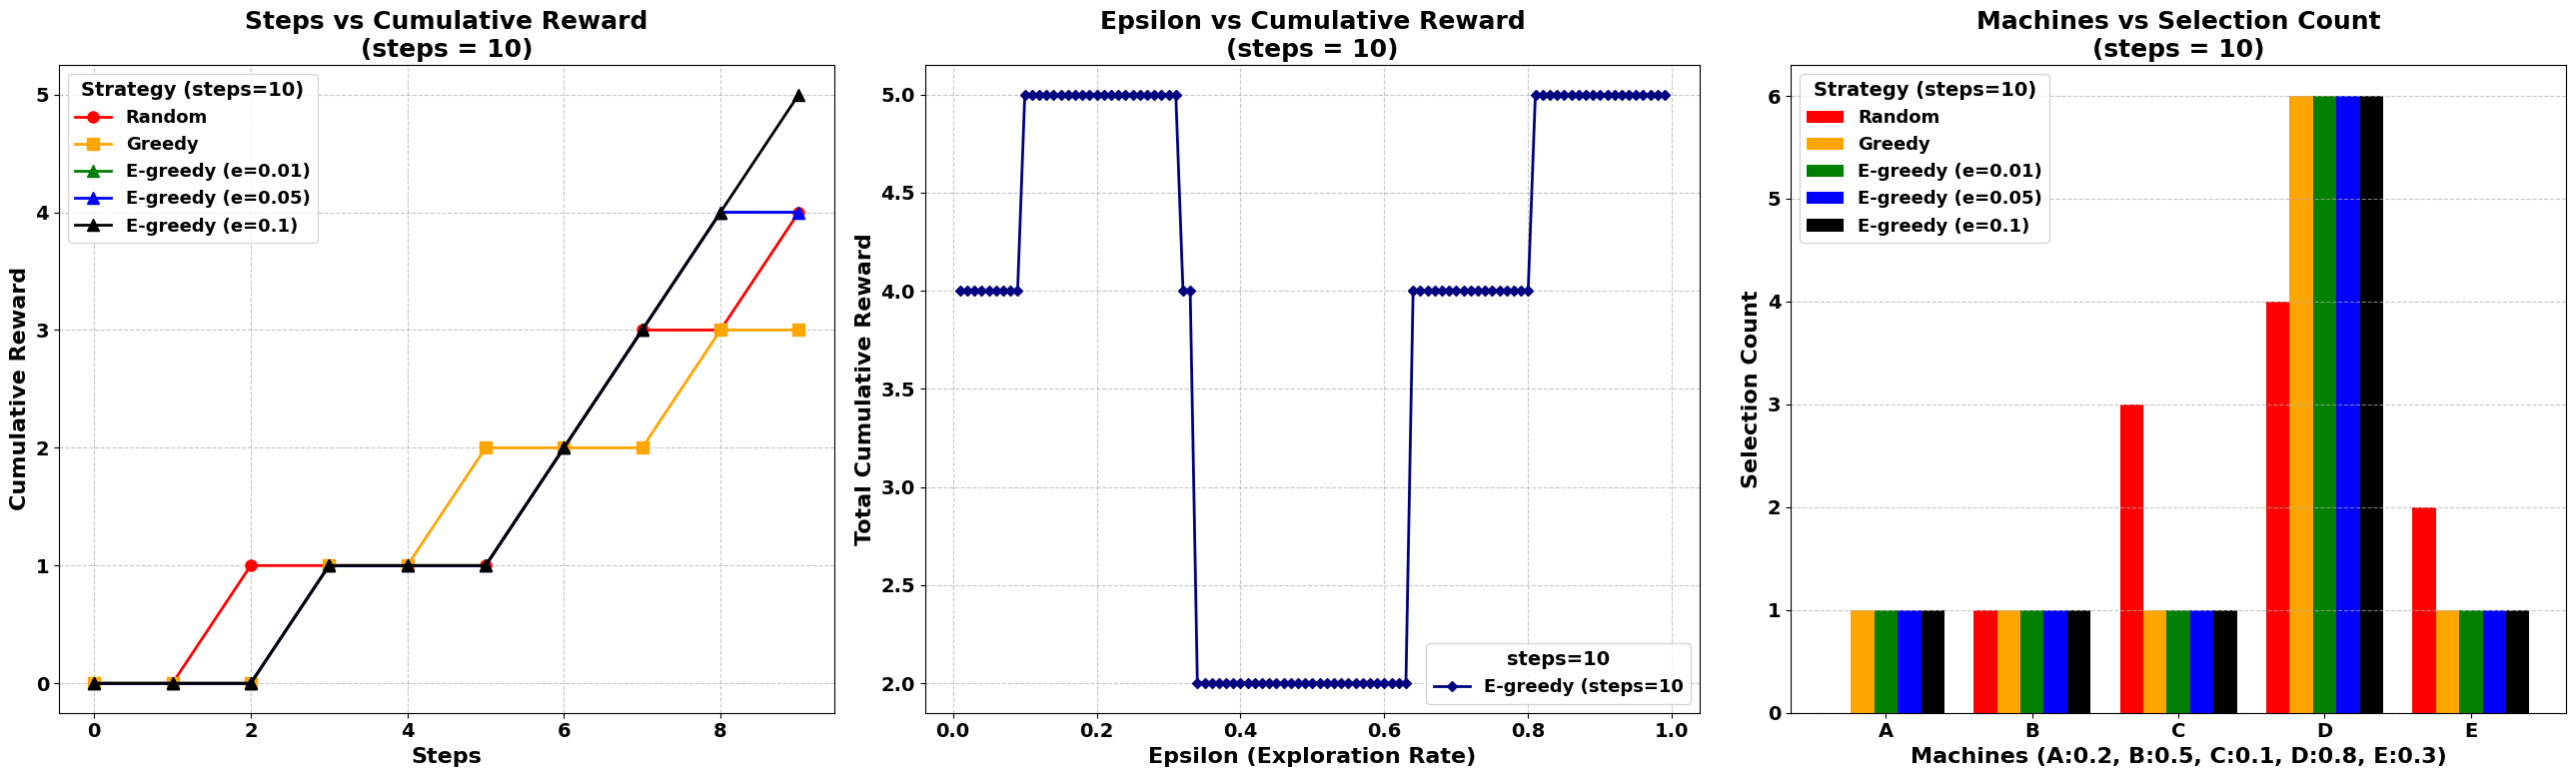

[Results/mab_results_steps_10.png] 및 CSV 데이터 파일들이 Results 폴더에 저장되었습니다.



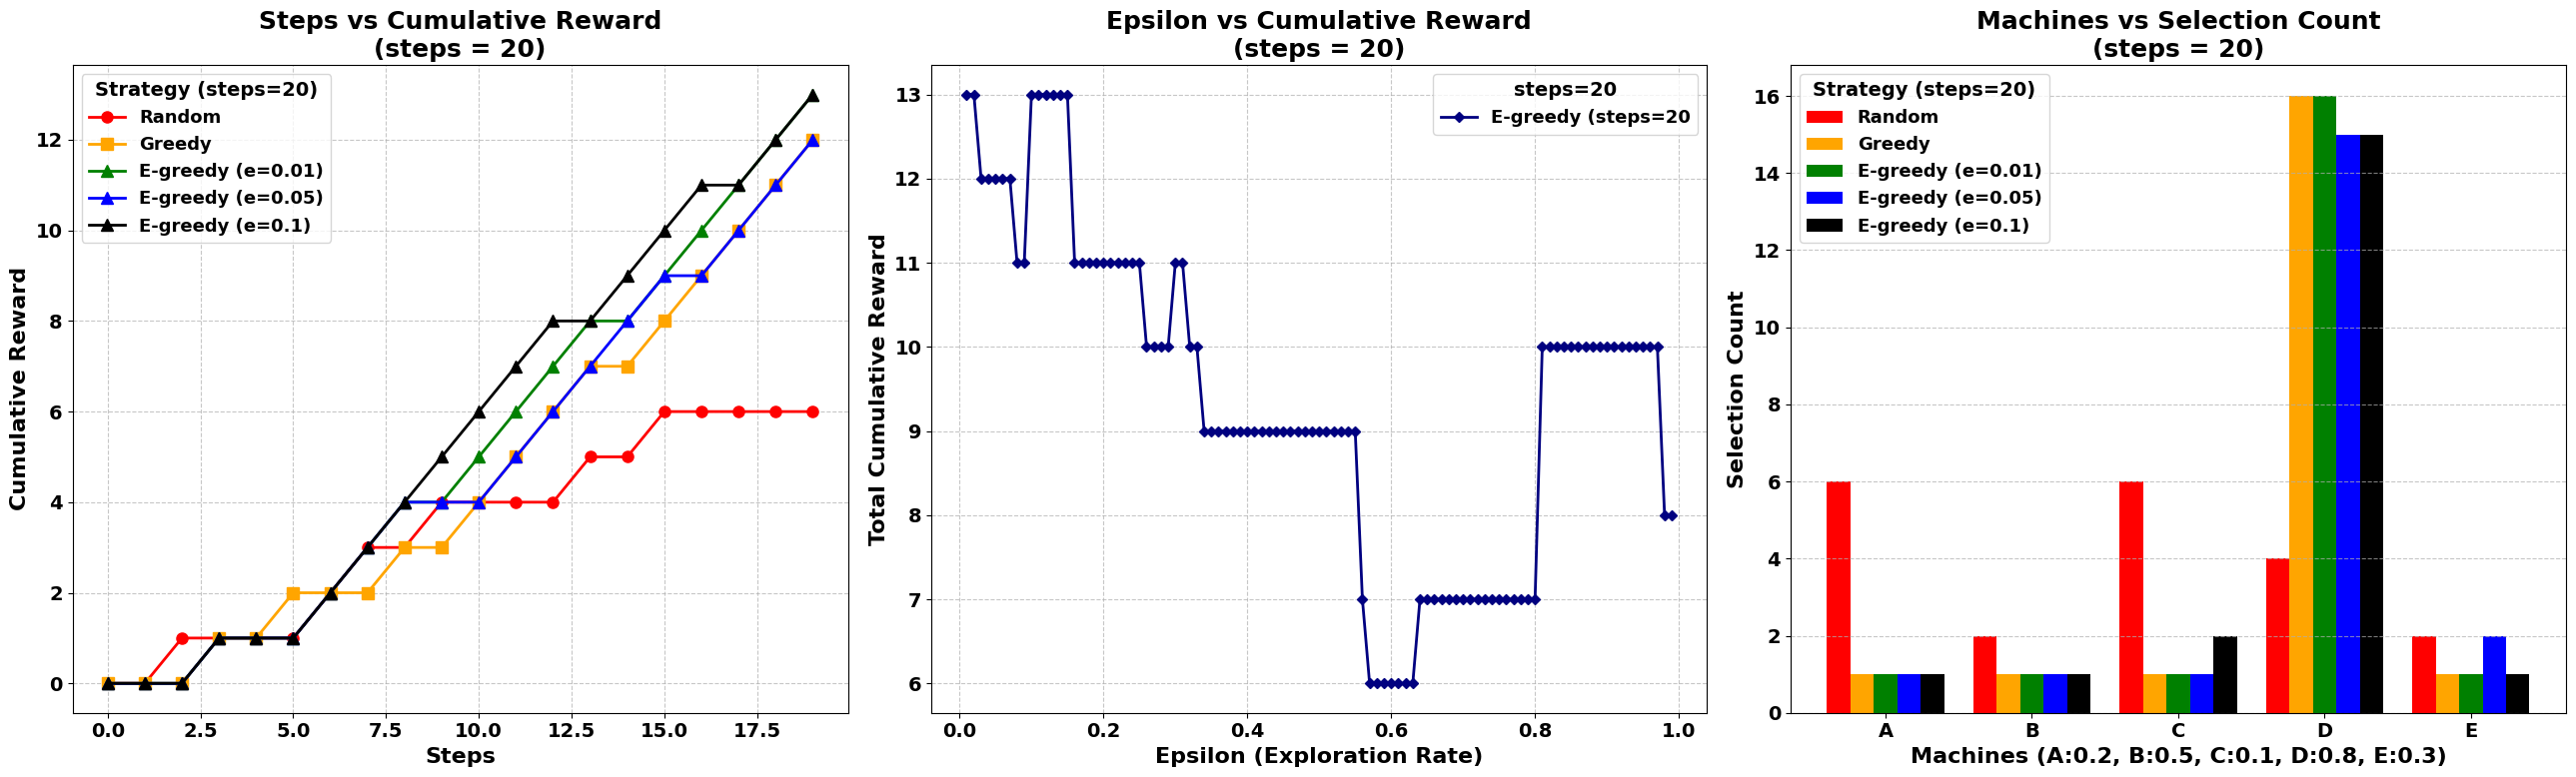

[Results/mab_results_steps_20.png] 및 CSV 데이터 파일들이 Results 폴더에 저장되었습니다.



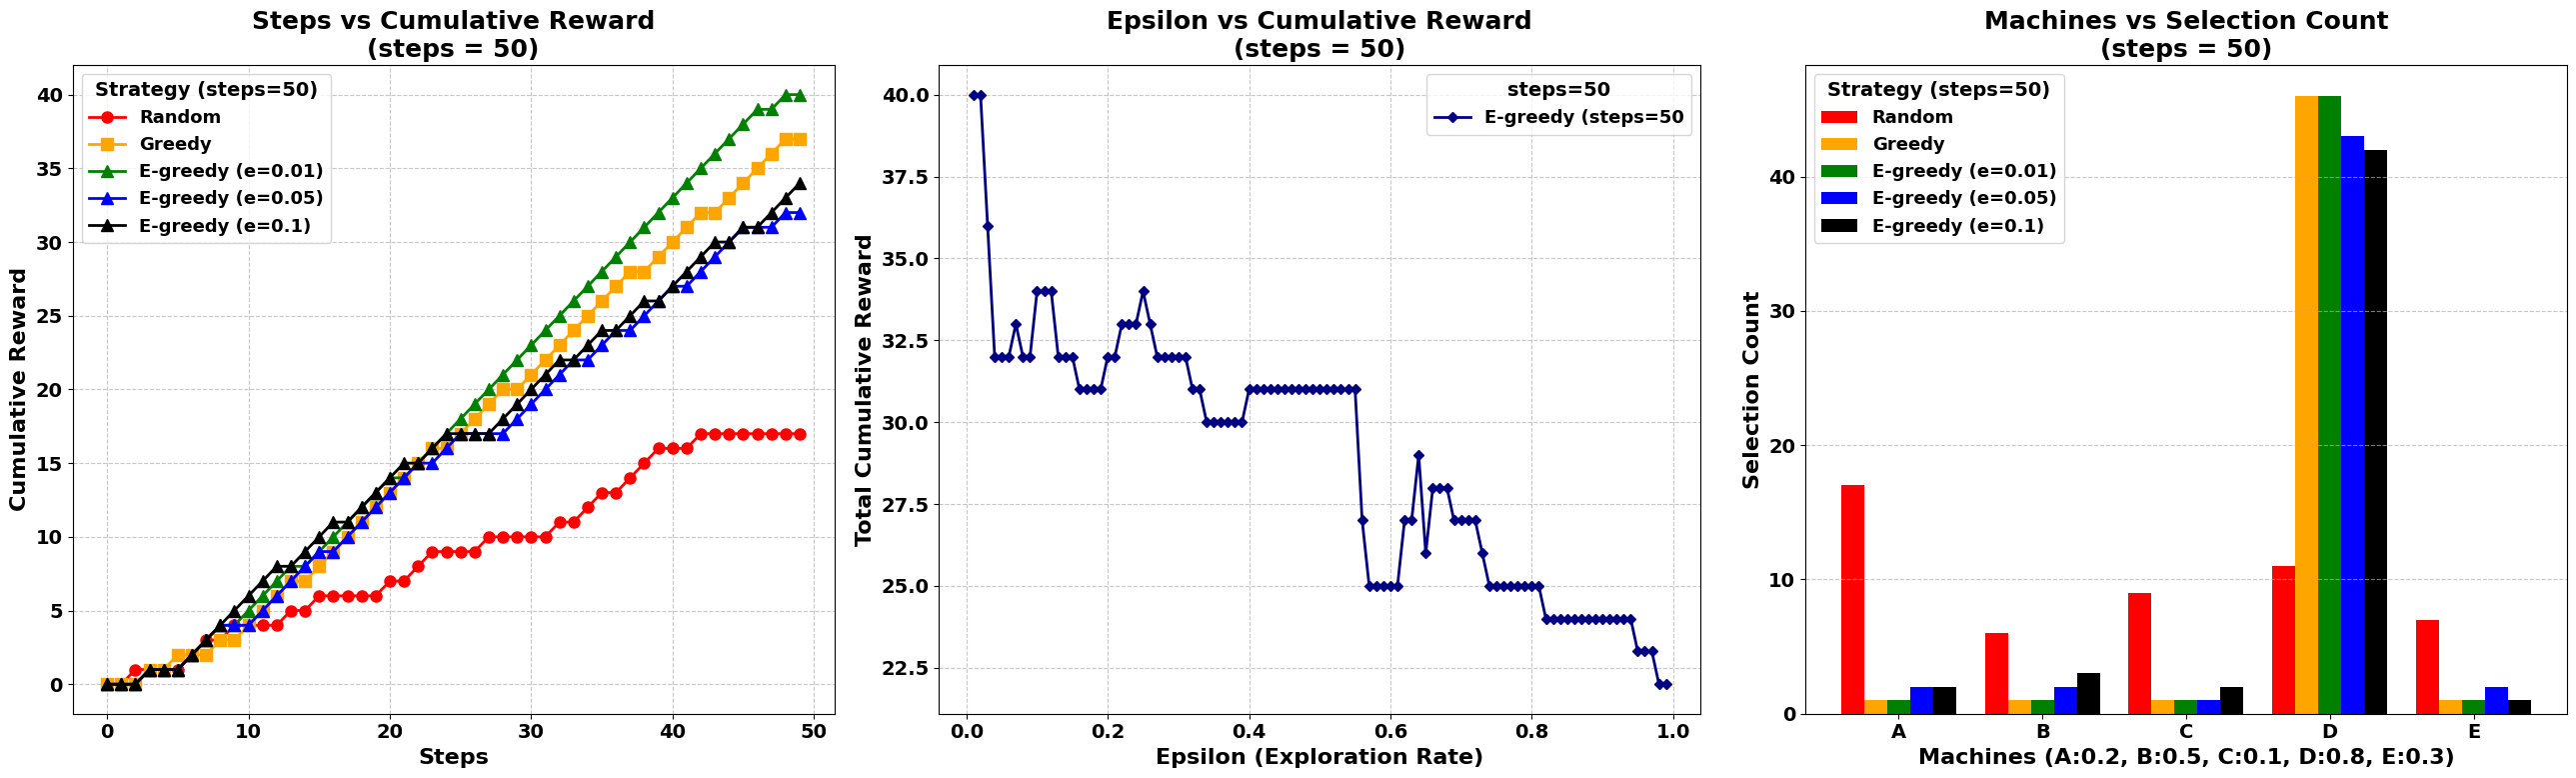

[Results/mab_results_steps_50.png] 및 CSV 데이터 파일들이 Results 폴더에 저장되었습니다.



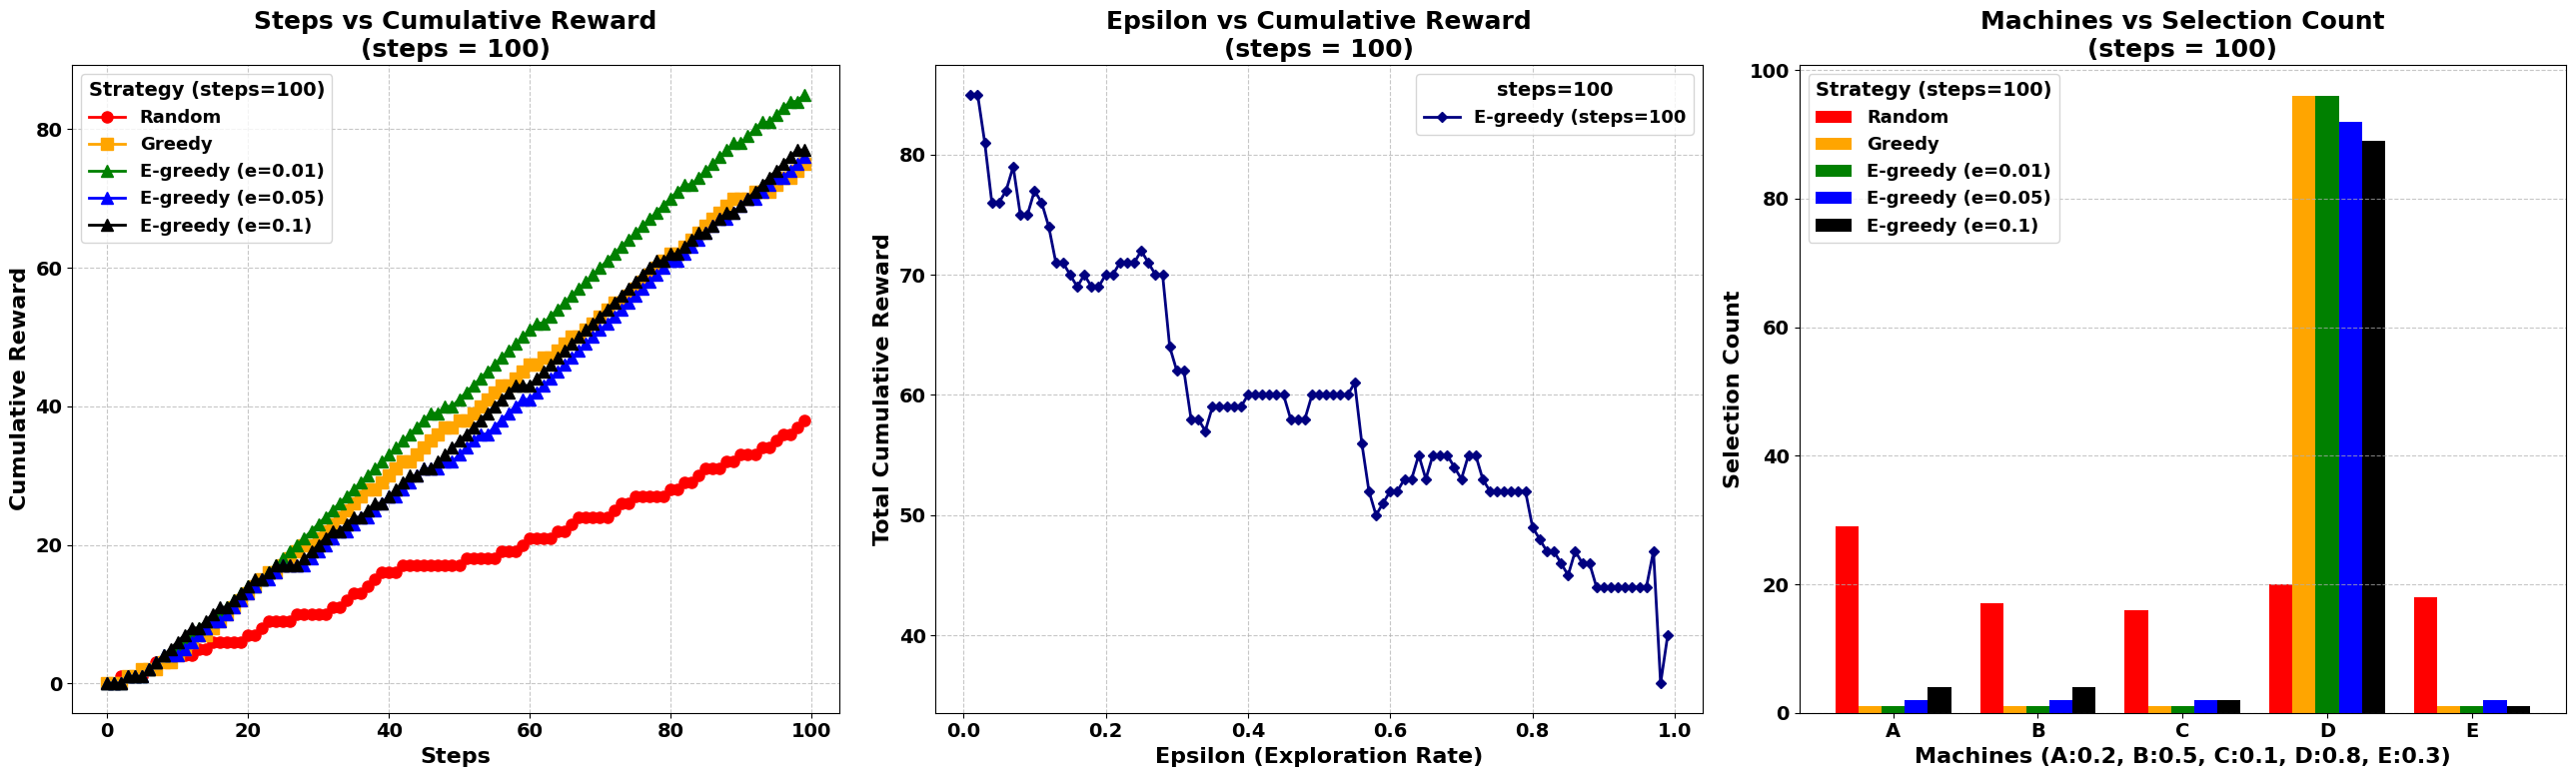

[Results/mab_results_steps_100.png] 및 CSV 데이터 파일들이 Results 폴더에 저장되었습니다.



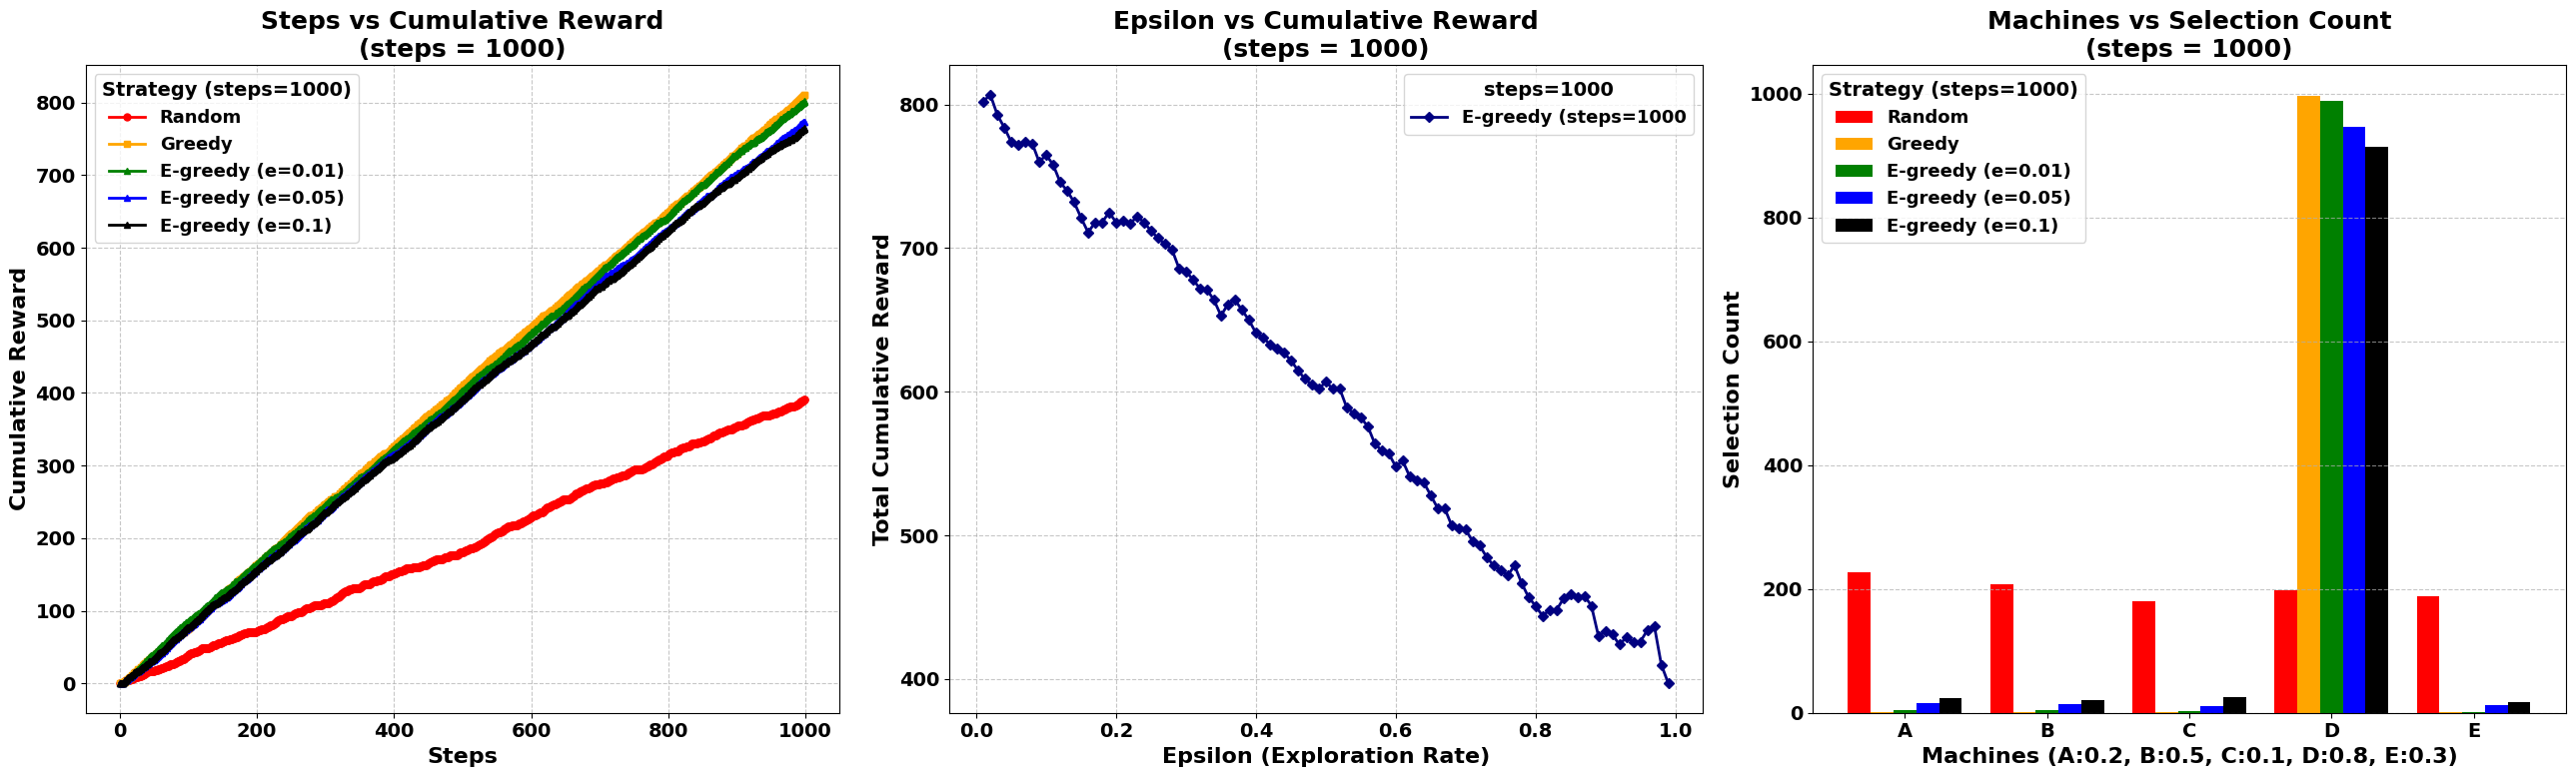

[Results/mab_results_steps_1000.png] 및 CSV 데이터 파일들이 Results 폴더에 저장되었습니다.

모든 VRAM 정리 및 프로세스 완료.


In [ ]:
# ─── 라이브러리 임포트 ───────────────────────────────────────
import numpy as np          # 배열 연산 및 누적합 계산
import pandas as pd         # 결과를 DataFrame으로 관리하고 CSV 저장
import matplotlib.pyplot as plt  # 그래프 시각화
import torch                # GPU 연산 및 난수 생성
import gc                   # 메모리 가비지 컬렉터
import os                   # 폴더 생성 등 파일시스템 조작

# ─── 1. 환경 및 시드 설정 ────────────────────────────────────
torch.manual_seed(2026)     # PyTorch 난수 시드 고정 (재현성 확보)
np.random.seed(2026)        # NumPy 난수 시드 고정

# 사용 가능한 디바이스(GPU/CPU) 자동 선택
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 디바이스: {device}")

# Results 폴더가 없으면 생성 (exist_ok=True: 이미 존재해도 오류 없음)
os.makedirs('Results', exist_ok=True)

# 5개 슬롯머신의 실제 보상 확률 (에이전트는 이 값을 모름)
# A=0.2, B=0.5, C=0.1, D=0.8(최적), E=0.3
arms_prob = torch.tensor([0.2, 0.5, 0.1, 0.8, 0.3], device=device)
n_arms = len(arms_prob)                    # 머신 수 = 5
machine_names = ['A', 'B', 'C', 'D', 'E'] # 그래프 x축 레이블용

# ─── 2. MAB 시뮬레이션 함수 ─────────────────────────────────
def run_bandit(strategy, epsilon=0.0, n_steps=1000, seed=2026):
    """
    단일 전략으로 n_steps 스텝 동안 MAB를 시뮬레이션한다.

    Args:
        strategy (str) : 'Random' | 'Greedy' | 'Epsilon-greedy'
        epsilon  (float): ε-greedy의 탐색 비율 (strategy='Epsilon-greedy'일 때만 사용)
        n_steps  (int)  : 총 시뮬레이션 스텝 수
        seed     (int)  : 재현성을 위한 난수 시드

    Returns:
        cum_rewards      (np.ndarray): 스텝별 누적 보상 배열 (길이=n_steps)
        selections_record (list)     : 스텝별 선택한 머신 인덱스 목록
    """
    torch.manual_seed(seed)

    # Q값(추정 평균 보상)과 각 머신의 선택 횟수를 0으로 초기화
    q_values = torch.zeros(n_arms, device=device)
    counts   = torch.zeros(n_arms, device=device)

    rewards_record    = []  # 스텝별 실제 보상 기록
    selections_record = []  # 스텝별 선택 머신 인덱스 기록

    for step in range(n_steps):
        # ── 행동 선택 (Action Selection) ──────────────────────
        if strategy == 'Random':
            # 완전 무작위: 매 스텝 0~4 중 하나를 균일 확률로 선택
            action = torch.randint(0, n_arms, (1,), device=device).item()

        elif step < n_arms:
            # 초기 탐색 단계(Greedy/ε-greedy 공통):
            # 첫 n_arms 스텝 동안 각 머신을 순서대로 한 번씩 당겨
            # 모든 머신에 대한 초기 Q값을 확보한다.
            action = step

        else:
            # 초기 탐색 이후: 전략에 따라 행동 결정
            if strategy == 'Greedy':
                # 순수 탐욕: 현재 Q값이 가장 높은 머신만 선택
                action = torch.argmax(q_values).item()

            elif strategy == 'Epsilon-greedy':
                if torch.rand(1, device=device).item() < epsilon:
                    # 탐색(Exploration): ε 확률로 무작위 머신 선택
                    action = torch.randint(0, n_arms, (1,), device=device).item()
                else:
                    # 활용(Exploitation): (1-ε) 확률로 최고 Q값 머신 선택
                    action = torch.argmax(q_values).item()

        # ── 보상 획득 (Reward) ────────────────────────────────
        # 선택한 머신의 실제 당첨 확률로 베르누이 시행: 1(당첨) 또는 0(꽝)
        reward = 1.0 if torch.rand(1, device=device).item() < arms_prob[action].item() else 0.0

        # ── Q값 업데이트 (Incremental Mean Update) ───────────
        counts[action]   += 1
        # 표본 평균을 점진적으로 갱신: Q ← Q + (reward - Q) / n
        q_values[action] += (reward - q_values[action]) / counts[action]

        rewards_record.append(reward)
        selections_record.append(action)

    # 스텝별 누적합으로 누적 보상 계산
    cum_rewards = np.cumsum(rewards_record)
    return cum_rewards, selections_record

# ─── 시뮬레이션 파라미터 ─────────────────────────────────────
# 비교할 총 스텝 수 목록 (적은 스텝 → 많은 스텝 순으로 변화 관찰)
step_list = [10, 20, 50, 100, 1000]

# 전략별 선 색상 지정 (1열·3열 그래프에서 일관되게 사용)
color_map = {
    'Random':            'red',
    'Greedy':            'orange',
    'E-greedy (e=0.01)': 'green',
    'E-greedy (e=0.05)': 'blue',
    'E-greedy (e=0.1)':  'black'
}

# 전략별 마커(심벌) 지정
marker_map = {
    'Random':            'o',  # 원형
    'Greedy':            's',  # 사각형
    'E-greedy (e=0.01)': '^',  # 삼각형
    'E-greedy (e=0.05)': '^',
    'E-greedy (e=0.1)':  '^'
}

# ─── 3. 전역 그래프 스타일 설정 ──────────────────────────────
# 모든 서브플롯에 적용될 폰트 크기·굵기를 한 번에 설정
plt.rcParams.update({
    'font.size':            14,
    'font.weight':          'bold',
    'axes.labelweight':     'bold',
    'axes.titleweight':     'bold',
    'axes.titlesize':       18,
    'axes.labelsize':       16,
    'legend.fontsize':      13,
    'legend.title_fontsize':14,
    'xtick.labelsize':      14,
    'ytick.labelsize':      14
})

# ─── 4. 스텝별 시뮬레이션 루프 ───────────────────────────────
for steps in step_list:

    # 비교할 5가지 전략 정의: {표시이름: (전략종류, epsilon값)}
    strategies = {
        'Random':            ('Random',          0.0),
        'Greedy':            ('Greedy',           0.0),
        'E-greedy (e=0.01)': ('Epsilon-greedy',  0.01),
        'E-greedy (e=0.05)': ('Epsilon-greedy',  0.05),
        'E-greedy (e=0.1)':  ('Epsilon-greedy',  0.1)
    }

    results_cum = {}  # 전략별 누적 보상 저장
    results_sel = {}  # 전략별 머신 선택 인덱스 저장

    # 각 전략으로 시뮬레이션 실행 후 결과 수집
    for name, (strat, eps) in strategies.items():
        cum_rew, sel = run_bandit(strat, eps, n_steps=steps)
        results_cum[name] = cum_rew
        results_sel[name] = sel

    # 결과를 DataFrame으로 변환 (행=스텝, 열=전략)
    df_cum = pd.DataFrame(results_cum)  # 누적 보상 테이블
    df_sel = pd.DataFrame(results_sel)  # 머신 선택 테이블

    # CSV 파일로 저장 (index_label='Step'으로 스텝 번호 열 이름 지정)
    df_cum.to_csv(f'Results/cumulative_rewards_steps_{steps}.csv', index_label='Step')
    df_sel.to_csv(f'Results/machine_selections_steps_{steps}.csv', index_label='Step')

    # ── ε 최적값 탐색 시뮬레이션 (2열 그래프용) ──────────────
    # ε를 0.01~0.99 구간에서 0.01 단위로 변화시키며
    # 각 ε에서의 최종 누적 보상을 기록 → 최적 ε 시각화에 사용
    eps_values      = np.arange(0.01, 1.00, 0.01)
    optimal_rewards = []
    for eps in eps_values:
        cum_rew, _ = run_bandit('Epsilon-greedy', eps, n_steps=steps)
        optimal_rewards.append(cum_rew[-1])  # 마지막 스텝의 누적 보상만 저장

    # ─────────────────────────────────────────────────────────
    #  그래프 구성: 1행 3열
    #  [1열] 스텝 vs 누적 보상  |  [2열] ε vs 누적 보상  |  [3열] 머신 선택 횟수
    # ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(26, 8))

    # ── [1열] Steps vs Cumulative Reward ─────────────────────
    # 전략별로 꺾은선 그래프를 겹쳐 그려 누적 보상 추이를 비교
    for col in df_cum.columns:
        axes[0].plot(
            df_cum.index, df_cum[col],
            color=color_map[col],
            marker=marker_map[col],
            linestyle='-',
            label=col,
            linewidth=2,
            markersize=5 if steps >= 1000 else 8  # 스텝이 많으면 마커 작게
        )
    axes[0].set_title(f'Steps vs Cumulative Reward\n(steps = {steps})')
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Cumulative Reward')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].legend(title=f'Strategy (steps={steps})')
    for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
        label.set_fontweight('bold')

    # ── [2열] Epsilon vs Cumulative Reward ───────────────────
    # ε 값에 따른 최종 누적 보상 변화를 보여줘 최적 ε 구간을 파악
    axes[1].plot(
        eps_values, optimal_rewards,
        color='navy',
        marker='D',        # 남색 마름모 마커
        linestyle='-',
        label=f'E-greedy (steps={steps}',  # 오른쪽 괄호 제거
        linewidth=2,
        markersize=5
    )
    axes[1].set_title(f'Epsilon vs Cumulative Reward\n(steps = {steps})')
    axes[1].set_xlabel('Epsilon (Exploration Rate)')
    axes[1].set_ylabel('Total Cumulative Reward')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].legend(title=f'steps={steps}')
    for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
        label.set_fontweight('bold')

    # ── [3열] Machines vs Selection Count ────────────────────
    # 각 전략이 머신 A~E를 몇 번 선택했는지 묶음 막대그래프로 비교
    # → 전략별로 최적 머신(D)에 얼마나 집중하는지 한눈에 파악 가능
    sel_counts = {
        col: [df_sel[col].tolist().count(i) for i in range(n_arms)]
        for col in df_sel.columns
    }
    df_sel_counts = pd.DataFrame(sel_counts, index=machine_names)
    colors_bar = [color_map[col] for col in df_sel_counts.columns]

    df_sel_counts.plot(kind='bar', ax=axes[2], color=colors_bar, width=0.8, rot=0)
    axes[2].set_title(f'Machines vs Selection Count\n(steps = {steps})')
    axes[2].set_xlabel('Machines (A:0.2, B:0.5, C:0.1, D:0.8, E:0.3)')
    axes[2].set_ylabel('Selection Count')
    axes[2].grid(axis='y', linestyle='--', alpha=0.7)
    axes[2].legend(title=f'Strategy (steps={steps})')
    for label in axes[2].get_xticklabels() + axes[2].get_yticklabels():
        label.set_fontweight('bold')

    plt.tight_layout()

    # PNG 파일로 저장 후 화면 출력
    save_filename = f'Results/mab_results_steps_{steps}.png'
    plt.savefig(save_filename)
    plt.show()
    print(f"[{save_filename}] 및 CSV 데이터 파일들이 Results 폴더에 저장되었습니다.\n")

# ─── 5. 메모리 정리 ──────────────────────────────────────────
# GPU VRAM 캐시를 비우고 Python 가비지 컬렉터를 수동 실행
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print("모든 VRAM 정리 및 프로세스 완료.")

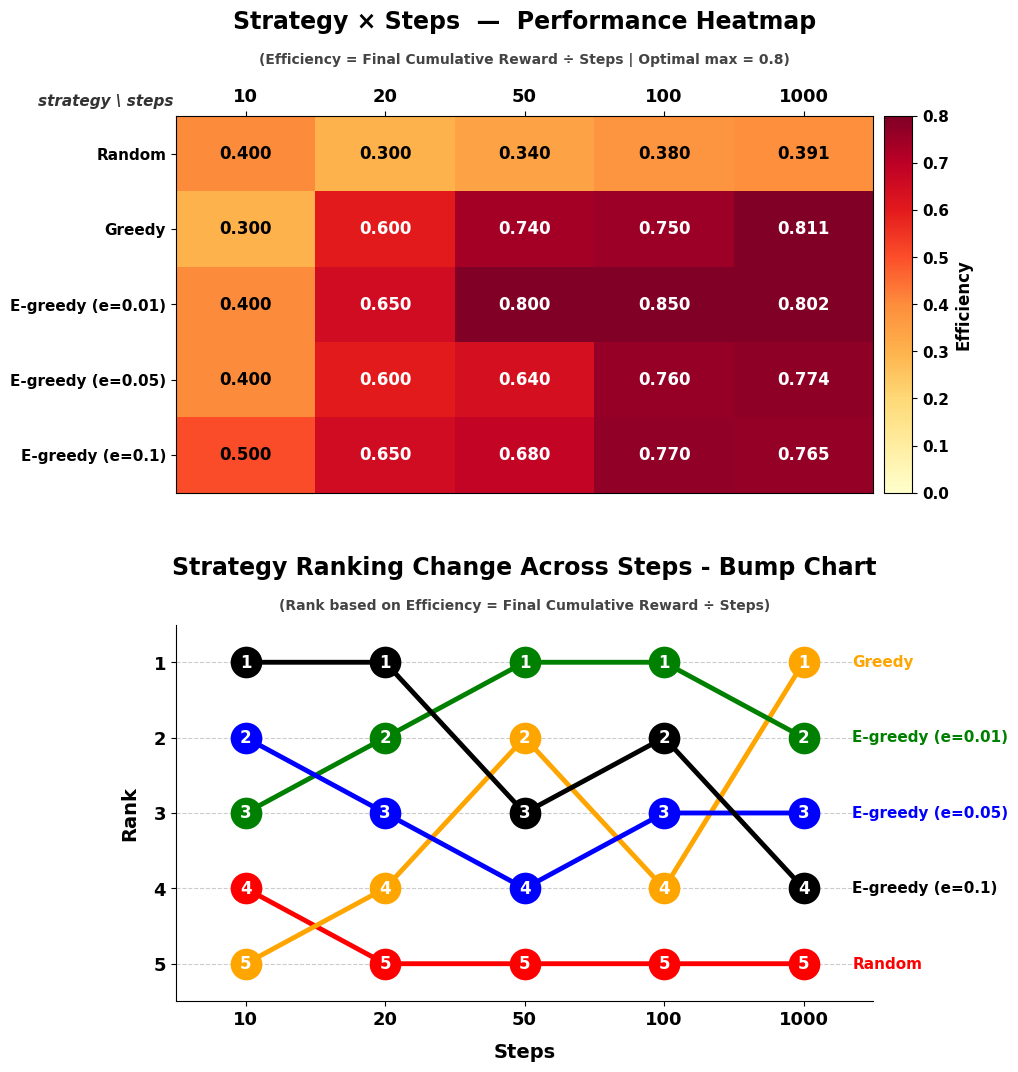

[Results/mab_combined.png] 저장 완료


In [ ]:
# ─── 결과 종합 정리 : 2행 1열 시각화 (steps 세로 위치 정렬) ─────────────
# 1행: Strategy × Steps  —  Performance Heatmap
# 2행: Strategy Ranking Change Across Steps  —  Bump Chart
#
# [정렬 방법]
#   · GridSpec 2행×2열: col 0 = 두 그래프 공통 영역, col 1 = 컬러바/여백
#   · ax2(sharex=ax1): 히트맵 imshow가 설정한 xlim[-0.5, 4.5]를 공유
#   · 동일 xlim + 동일 axes 폭 → steps 10/20/50/100/1000 세로 위치 완전 일치
#   · Bump Chart 전략명 레이블: blended transform (x=transAxes, y=data)
#     → xlim 변경에 무관하게 axes 우측 바깥 고정 위치에 배치
# ─────────────────────────────────────────────────────────────────────────

from matplotlib.gridspec import GridSpec
import matplotlib.transforms as transforms

step_list_v    = [10, 20, 50, 100, 1000]
strategy_order = ['Random', 'Greedy', 'E-greedy (e=0.01)', 'E-greedy (e=0.05)', 'E-greedy (e=0.1)']
strategy_cfg_v = {
    'Random':            ('Random',          0.0),
    'Greedy':            ('Greedy',          0.0),
    'E-greedy (e=0.01)': ('Epsilon-greedy', 0.01),
    'E-greedy (e=0.05)': ('Epsilon-greedy', 0.05),
    'E-greedy (e=0.1)':  ('Epsilon-greedy',  0.1),
}

n_strat = len(strategy_order)
n_step  = len(step_list_v)

# ── 효율 행렬 및 순위 행렬 계산 (두 그래프 공통) ─────────────────────────
eff_v = np.zeros((n_strat, n_step))
for i, name in enumerate(strategy_order):
    strat, eps = strategy_cfg_v[name]
    for j, steps in enumerate(step_list_v):
        cum_rew, _ = run_bandit(strat, eps, n_steps=steps)
        eff_v[i, j] = cum_rew[-1] / steps

rank_v = np.zeros_like(eff_v, dtype=int)
for j in range(n_step):
    sorted_idx = np.argsort(eff_v[:, j])[::-1]
    for rank, idx in enumerate(sorted_idx):
        rank_v[idx, j] = rank + 1

# ── GridSpec: 2행×2열 ────────────────────────────────────────────────────
#   col 0: 그래프 영역 (ax1, ax2 동일 폭)
#   col 1: 히트맵 컬러바(cax) + 범프 차트 우측 여백(ax_dummy) — 폭 균형 유지
fig = plt.figure(figsize=(9.5, 11.5))
gs  = GridSpec(2, 2, figure=fig,
               width_ratios=[1, 0.04],
               height_ratios=[1, 1],
               hspace=0.35, wspace=0.03)

ax1      = fig.add_subplot(gs[0, 0])              # 히트맵 axes
cax      = fig.add_subplot(gs[0, 1])              # 컬러바 전용 axes
ax2      = fig.add_subplot(gs[1, 0], sharex=ax1)  # 범프 차트 (xlim=ax1 공유)
ax_dummy = fig.add_subplot(gs[1, 1])              # 우측 여백 균형용 (비표시)
ax_dummy.set_visible(False)

x_pos = list(range(n_step))

# ══════════════════════════════════════════════════════════════════════════
# ① [1행] 히트맵
# ══════════════════════════════════════════════════════════════════════════
im = ax1.imshow(eff_v, cmap='YlOrRd', aspect='auto', vmin=0.0, vmax=0.8)
# imshow → ax1.xlim = [-0.5, 4.5] 자동 설정; ax2도 sharex로 동일 적용

# X축: 상단 배치, 레이블 명시적으로 표시
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
ax1.set_xticks(range(n_step))
ax1.set_xticklabels([str(s) for s in step_list_v], fontsize=13, fontweight='bold')
ax1.tick_params(labeltop=True, labelbottom=False)
ax1.set_xlabel('')

# Y축: 전략명
ax1.set_yticks(range(n_strat))
ax1.set_yticklabels(strategy_order, fontsize=11, fontweight='bold')
ax1.set_ylabel('')

# 'strategy \ steps' 코너 레이블
ax1.text(-0.10, 1.04, 'strategy \\ steps',
         transform=ax1.transAxes,
         fontsize=11, fontweight='bold', fontstyle='italic',
         ha='center', va='center', color='#333333', clip_on=False)

# 셀 수치 표기
for i in range(n_strat):
    for j in range(n_step):
        val = eff_v[i, j]
        txt_color = 'white' if val >= 0.58 else 'black'
        ax1.text(j, i, f'{val:.3f}',
                 ha='center', va='center',
                 fontsize=12, fontweight='bold', color=txt_color)

# 컬러바: cax에 배치 → ax1 폭에 영향 없음
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Efficiency', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

# 주 제목 + 부제목
ax1.text(0.5, 1.25,
         'Strategy × Steps  —  Performance Heatmap',
         transform=ax1.transAxes,
         fontsize=17, fontweight='bold',
         ha='center', va='center', clip_on=False)
ax1.text(0.5, 1.15,
         '(Efficiency = Final Cumulative Reward ÷ Steps | Optimal max = 0.8)',
         transform=ax1.transAxes,
         fontsize=10, ha='center', va='center',
         color='#444444', clip_on=False)

# ══════════════════════════════════════════════════════════════════════════
# ② [2행] Bump Chart
# ══════════════════════════════════════════════════════════════════════════
for i, name in enumerate(strategy_order):
    ranks = rank_v[i, :]
    c     = color_map[name]
    ax2.plot(x_pos, ranks,
             color=c, linewidth=3.5, zorder=2,
             solid_capstyle='round', solid_joinstyle='round')
    for j, r in enumerate(ranks):
        ax2.scatter(j, r, s=520, color=c, zorder=3, linewidths=0)
        ax2.text(j, r, str(r),
                 ha='center', va='center',
                 color='white', fontsize=12, fontweight='bold', zorder=4)

# 전략명 레이블: 오른쪽(steps=1000 기준)만 표시
# blended transform (x=transAxes, y=data좌표) → xlim 변경에 무관
trans_bc = transforms.blended_transform_factory(ax2.transAxes, ax2.transData)
for i, name in enumerate(strategy_order):
    ax2.text(0.97, rank_v[i, -1], name,
             transform=trans_bc,
             ha='left', va='center',
             color=color_map[name], fontsize=11, fontweight='bold', clip_on=False)

# X축: sharex로 xlim 공유, 레이블만 별도 설정
ax2.tick_params(labelbottom=True)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([str(s) for s in step_list_v], fontsize=13, fontweight='bold')
ax2.set_xlabel('Steps', fontsize=14, fontweight='bold', labelpad=10)

# Y축
ax2.set_yticks([1, 2, 3, 4, 5])
ax2.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=13, fontweight='bold')
ax2.set_ylabel('Rank', fontsize=14, fontweight='bold', labelpad=10)
ax2.invert_yaxis()
ax2.set_ylim(5.5, 0.5)

# 수평 격자선
for r in [1, 2, 3, 4, 5]:
    ax2.axhline(r, color='grey', linestyle='--', linewidth=0.8, alpha=0.4, zorder=1)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 주 제목 + 부제목
ax2.text(0.5, 1.15,
         'Strategy Ranking Change Across Steps - Bump Chart',
         transform=ax2.transAxes,
         fontsize=17, fontweight='bold',
         ha='center', va='center', clip_on=False)
ax2.text(0.5, 1.05,
         '(Rank based on Efficiency = Final Cumulative Reward ÷ Steps)',
         transform=ax2.transAxes,
         fontsize=10, ha='center', va='center',
         color='#444444', clip_on=False)

plt.savefig('Results/mab_combined.png', bbox_inches='tight', dpi=150)
plt.show()
print("[Results/mab_combined.png] 저장 완료")

## 결과 분석 및 질문 답변

---

### 1. 문제 상황 및 핵심 개념

- 카지노에 슬롯머신 5대(A~E)가 놓여 있다.
- 각 머신의 당첨 확률은 서로 다르고(A=0.2, B=0.5, C=0.1, D=0.8, E=0.3), 플레이어는 이 값을 미리 알 수 없다.
- 직접 머신 레버를 당겨보며 결과를 관찰하고, 제한된 시도 횟수 안에서 가능한 한 많은 누적 보상을 얻어야 한다.
- 이것이 **Multi-Armed Bandit(MAB)** 문제이다.

이 상황에서 에이전트는 매 스텝마다 두 가지 행동 중 하나를 선택해야 한다.

| 행동 | 설명 | 장점 | 단점 |
|---|---|---|---|
| **Exploration (탐색)** | 아직 잘 모르는 머신을 당겨 정보를 수집한다 | 더 좋은 머신을 발견할 수 있다 | 지금 당장의 보상이 낮을 수 있다 |
| **Exploitation (활용)** | 지금까지 가장 좋다고 알려진 머신을 선택한다 | 즉각적인 보상이 안정적이다 | 더 좋은 머신을 영영 놓칠 수 있다 |

탐색과 활용의 균형을 어떻게 잡느냐가 MAB 문제의 핵심이며, 이 실험은 세 가지 전략을 통해 그 균형의 차이를 비교한다.

---

### 2. 세 가지 전략의 작동 방식

**2-1. Random (무작위)**

- 매 스텝 5개 머신 중 하나를 완전히 무작위로 선택한다.
- 학습이 전혀 없으므로 어떤 정보도 축적되지 않으며, 최적 머신(D, 확률=0.8)이 선택될 확률은 항상 20%에 머문다.
- 다른 전략과 성능을 비교하기 위한 기준선(Baseline) 역할을 한다.

**2-2. Greedy (탐욕)**

- 초기에 각 머신을 한 번씩 순차적으로 탐색한 뒤, 추정 평균 보상(Q값)이 가장 높은 머신만 계속 선택한다.
- 탐색이 단 1회로 끝나기 때문에 초기 결과가 운에 크게 좌우된다.
- 초기 탐색에서 최적 머신을 올바르게 식별하면 높은 성능을 보이지만, 그렇지 못하면 회복이 불가능하다.

**2-3. ε-greedy (엡실론 탐욕)**

- 매 스텝 ε 확률로 무작위 탐색(Exploration), (1-ε) 확률로 현재 최선의 머신을 선택(Exploitation)한다.
- ε이라는 파라미터 하나로 탐색과 활용의 비율을 조절하며, 이 실험에서는 ε = 0.01 / 0.05 / 0.1 세 가지 값으로 비교한다.

---

### 3. 실험 결과 분석

**출력 결과물 목록**

| 파일명 | 내용 |
|---|---|
| `mab_results_steps_10.png` | steps=10 : [누적 보상 추이 / ε 탐색 / 머신 선택 횟수] 3종 그래프 |
| `mab_results_steps_20.png` | steps=20 : 동일 구성 |
| `mab_results_steps_50.png` | steps=50 : 동일 구성 |
| `mab_results_steps_100.png` | steps=100 : 동일 구성 |
| `mab_results_steps_1000.png` | steps=1000 : 동일 구성 |
| `mab_combined.png` | **[1행]** 전략×스텝 효율 히트맵 + **[2행]** 전략 순위 변화 Bump Chart |

---

**Q1. Greedy 전략은 왜 실패할 수 있나?**

- Greedy는 초기 탐색 단 1회로 얻은 정보만으로 최선의 머신을 결정하고, 이후 다른 머신을 다시 시도하지 않는다.
- 보상이 베르누이 확률로 지급되기 때문에 1~2번의 시도 결과는 실제 평균과 크게 다를 수 있다.

> 예시: D머신(실제 확률 0.8)이 초기에 운 나쁘게 '꽝(0)'이 나오고, B머신(실제 확률 0.5)이 '당첨(1)'이 나오면, Greedy는 B를 최선으로 고정한다. 이후 D를 다시 시도하지 않으므로 최적 머신을 끝까지 발견하지 못한다.

- `mab_results_steps_1000.png` [3열] 막대그래프: Greedy(주황)는 최적 머신 D가 아닌 다른 머신에 선택이 집중되는 경우가 나타난다.
- `mab_combined.png` [1행 히트맵]: Greedy 행의 수치가 steps가 늘어도 제자리걸음인 경우가 관찰된다.
- `mab_combined.png` [2행 Bump Chart]: Greedy의 순위가 steps 증가에 따라 하락하는 궤적이 선명하게 드러난다.

- 스텝이 아무리 많아도 초기 운이 나쁘면 회복이 불가능한 것이 Greedy의 근본적 한계다.
- 이 상태를 **국소 최적(Local Optimum)에 고착**되었다고 한다.

---

**Q2. ε가 너무 크면 어떤 문제가 발생할 수 있나?**

ε가 크면 탐색 비율이 높아져, 최적 머신을 이미 파악한 이후에도 계속 다른 머신을 무작위로 선택하게 된다.

> 예시: ε=0.9이면 매 스텝 90%를 무작위 탐색에 소비한다. 최적 머신(D)을 활용하는 비율이 10%에 불과하므로, 충분한 정보가 쌓인 후반부에도 불필요한 탐색이 계속되어 누적 보상이 낮아진다.

- `mab_results_steps_N.png` [2열] Epsilon vs Cumulative Reward: ε가 높아질수록 최종 누적 보상이 뚜렷하게 감소하는 우하향 구간이 관찰된다.
- `mab_combined.png` [1행 히트맵]: ε=0.1 행이 ε=0.05 행보다 1000스텝 구간 효율이 낮다. 정보가 충분히 쌓인 이후에도 탐색에 소비되는 비율이 높아 활용 기회를 스스로 줄이는 것이다.

---

**Q3. ε가 너무 작으면 어떤 문제가 발생하나?**

ε가 작으면 탐색 기회가 적어 초기에 잘못 학습된 정보를 수정할 기회가 거의 없다.

> 예시: ε=0.01이면 매 스텝 1%만 무작위 탐색에 쓴다. 초기에 D머신보다 B머신이 좋다고 잘못 학습되면 이를 수정할 기회가 평균 100스텝에 1번뿐이다. 특히 스텝 수가 적을 때(steps=10, 20)는 Greedy와 사실상 차이가 없다.

- `mab_results_steps_10.png` / `mab_results_steps_20.png` [1열]: ε=0.01(녹색)이 Greedy(주황)와 거의 같은 궤적을 그린다.
- `mab_combined.png` [1행 히트맵]: steps=10~20 구간에서 ε=0.01 셀 수치가 Greedy와 유사하다.
- `mab_combined.png` [2행 Bump Chart]: 단기(steps=10~20)에서 ε=0.01의 순위가 Greedy와 혼재하는 양상이 확인된다.

---

**Q4. Exploration(탐색)이 필요한 이유?**

- 각 머신의 실제 당첨 확률은 사전에 알 수 없고, 직접 시도해봐야만 추정할 수 있다.
- 탐색 없이 현재 알고 있는 정보만으로 최선을 선택(Exploit)하면, 더 좋은 머신이 존재해도 발견하지 못한 채 끝나버린다.

- 단기 관점: 탐색은 당장 손해처럼 보인다. 최적이 아닌 머신을 선택하기 때문이다.
- 장기 관점: 탐색이 쌓이면 각 머신의 실제 보상 확률이 점점 정확하게 추정되고, 최적 머신을 올바르게 선택할 수 있게 된다.

> **Exploration-Exploitation Tradeoff**: 탐색은 단기 손실이지만, 더 나은 선택지를 발견하여 장기 보상을 극대화하기 위한 필수 투자다.

- `mab_results_steps_1000.png` [1열]: ε=0.1(검정)은 초반에는 Greedy(주황)보다 낮을 수 있지만, 후반부로 갈수록 Greedy를 추월하여 최종적으로 더 높은 누적 보상을 달성한다.
- `mab_combined.png` [1행 히트맵]: ε-greedy 계열은 steps가 늘수록 셀 색상이 진해진다. Random(학습 없음)은 모든 steps에서 색상이 일정하게 낮다.
- `mab_combined.png` [2행 Bump Chart]: ε=0.1은 단기에서 낮은 순위를 보이다가 steps=1000에서 상위권으로 수렴한다. 탐색이 장기 순위 상승으로 이어지는 흐름이 선명하게 드러난다.

---

### 4. 핵심 요약

| 전략 | 탐색 수준 | 활용 수준 | 장기 성능 | 히트맵 특징 | Bump Chart 특징 |
|---|---|---|---|---|---|
| Random | 과도 (100%) | 없음 | 낮음 | 전 구간 균일하게 낮은 색상 | 하위 순위 고착 |
| Greedy | 초기 1회만 | 고정 활용 | 운에 좌우됨 | steps와 무관하게 수치 정체 | 장기 순위 하락 위험 |
| ε-greedy (ε=0.01) | 부족 | 이른 수렴 | 불안정 | 단기=Greedy 유사, 장기=최고 효율 | 단기 혼재 후 장기 상위 수렴 |
| ε-greedy (ε=0.05) | 균형 | 점진적 활용 | 높음 | steps 증가에 따라 꾸준히 개선 | 안정적 상위권 유지 |
| ε-greedy (ε=0.1) | 다소 높음 | 점진적 활용 | 높고 안정적⭐ | 단기 낮음 → 장기 안정 수렴 | 단기 하위 → 장기 최상위 수렴 |

- 정보가 충분하지 않은 초반에는 탐색을 통해 각 머신의 실제 성능을 파악하고, 정보가 쌓인 후반에는 최적 머신을 집중적으로 활용하는 전략이 장기적으로 가장 높은 누적 보상을 달성한다.
- ε-greedy는 이 균형을 ε 파라미터 하나로 제어하는 단순하면서도 효과적인 알고리즘이다.
- 히트맵은 "어느 전략이 어느 스텝 구간에서 얼마나 효율적인가"를 한 장에 요약하고, Bump Chart는 "스텝이 늘수록 전략 간 순위가 어떻게 역전되는가"를 시각적으로 보여준다.
- 두 그림을 함께 보면 탐색(Exploration)이 단기 손실임에도 불구하고 장기적으로 전략 순위를 끌어올리는 핵심 요인임을 명확히 확인할 수 있다.

In [ ]:
# End.